In [ ]:
from pathlib import Path
import os

# 你当前 notebook 在项目根目录（截图显示 test.ipynb 在 SRDM_R_in 下）
# 所以这里用相对路径没问题
BASE_MODEL_ID = "runwayml/stable-diffusion-v1-5"

PROMPT_TXT_PATH = "data/flux_reasoning_prompts_20k.txt"

CHECKPOINT_DIR = Path("logs/2026.03.03_02.24.58/checkpoints/checkpoint_11").resolve()
LORA_WEIGHT_NAME = "pytorch_lora_weights.bin"

# generation
HEIGHT, WIDTH = 512, 512
STEPS = 30
GUIDANCE = 7.5
SEED = 123

print("CWD:", os.getcwd())
print("CHECKPOINT_DIR:", CHECKPOINT_DIR, "exists:", CHECKPOINT_DIR.exists())
if CHECKPOINT_DIR.exists():
    print("Files:", [p.name for p in CHECKPOINT_DIR.iterdir()])

CWD: /Users/shuoxu/Desktop/科研自奖励扩散模型/第4阶段：创新点实验/3. SRDM（内生奖励r_in）/code/SRDM_R_in
CHECKPOINT_DIR: /Users/shuoxu/Desktop/科研自奖励扩散模型/第4阶段：创新点实验/3. SRDM（内生奖励r_in）/code/SRDM_R_in/logs/2026.03.03_02.24.58/checkpoints/checkpoint_12 exists: True
Files: ['random_states_0.pkl', 'pytorch_lora_weights.bin', 'optimizer.bin']


In [13]:
import random
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
dtype = torch.float16 if device == "cuda" else torch.float32  # mps 用 fp32 稳

print("device:", device, "dtype:", dtype)

device: mps dtype: torch.float32


In [14]:
from pathlib import Path

def pick_random_prompt(txt_path: str, seed: int = 0) -> str:
    random.seed(seed)
    p = Path(txt_path)
    assert p.exists(), f"Prompt txt not found: {p.resolve()}"
    lines = [ln.strip() for ln in p.read_text(encoding="utf-8").splitlines() if ln.strip()]
    assert len(lines) > 0, f"No prompts in: {p.resolve()}"
    return random.choice(lines)

prompt = pick_random_prompt(PROMPT_TXT_PATH, seed=0)
print("PROMPT:\n", prompt)

PROMPT:
 Tropical Caribbean blue hues dominate a serene still life composition featuring a tall cylindrical bottle, two ceramic bowls filled with vibrant green limes, and a soft pastel backdrop, showcasing the expertly curated color palette by HGTV.com.


In [15]:
pipe_base = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
).to(device)

# 可选：省显存
if hasattr(pipe_base, "enable_attention_slicing"):
    pipe_base.enable_attention_slicing()

In [21]:
assert CHECKPOINT_DIR.exists(), f"Checkpoint dir not found: {CHECKPOINT_DIR}"
assert (CHECKPOINT_DIR / LORA_WEIGHT_NAME).exists(), f"LoRA file not found: {(CHECKPOINT_DIR / LORA_WEIGHT_NAME)}"

pipe_lora = StableDiffusionPipeline.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
).to(device)

if hasattr(pipe_lora, "enable_attention_slicing"):
    pipe_lora.enable_attention_slicing()

pipe_lora.load_lora_weights(
    str(CHECKPOINT_DIR),
    weight_name=LORA_WEIGHT_NAME
)

# 可选：融合 LoRA（更快）
if hasattr(pipe_lora, "fuse_lora"):
    try:
        pipe_lora.fuse_lora()
    except Exception as e:
        print("fuse_lora failed (ignore):", e)

In [22]:
def gen(pipe, prompt, seed):
    g = torch.Generator(device=device).manual_seed(seed)
    img = pipe(
        prompt=prompt,
        height=HEIGHT,
        width=WIDTH,
        num_inference_steps=STEPS,
        guidance_scale=GUIDANCE,
        generator=g
    ).images[0]
    return img

img_base = gen(pipe_base, prompt, SEED)
img_lora = gen(pipe_lora, prompt, SEED)

100%|██████████| 30/30 [00:17<00:00,  1.74it/s]


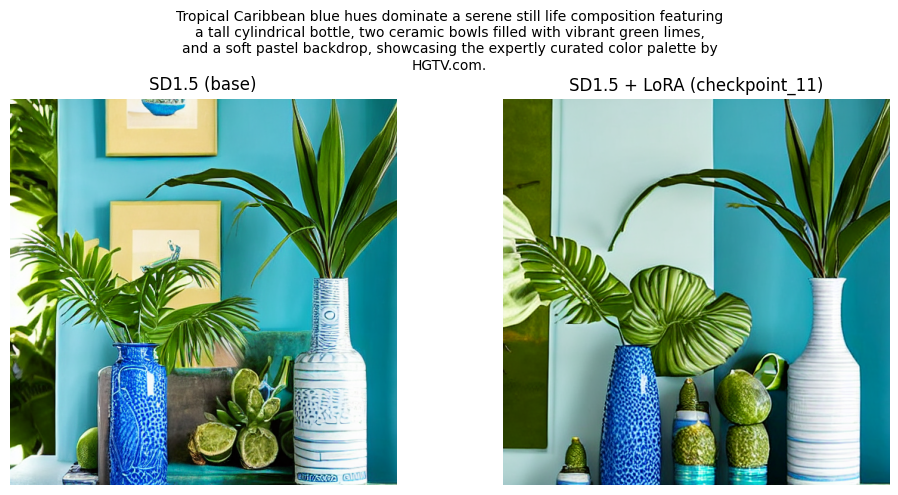

In [23]:
import textwrap

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.imshow(img_base)
plt.title("SD1.5 (base)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_lora)
plt.title("SD1.5 + LoRA (checkpoint_11)")
plt.axis("off")

plt.suptitle("\n".join(textwrap.wrap(prompt, 80)), fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path

out_dir = Path("compare_outputs")
out_dir.mkdir(exist_ok=True, parents=True)

img_base.save(out_dir / "base.png")
img_lora.save(out_dir / "lora_checkpoint_11.png")

print("Saved to:", out_dir.resolve())